# 002 Orderbook Heatmap

Цель: визуализация стакана в виде тепловой карты (уровни × время, цвет = размер).

In [8]:
import sys
from pathlib import Path

import pandas as pd

# Root проекта
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
root = next((p for p in candidates if (p / "pyproject.toml").exists()), Path.cwd())
if (root / "research").is_dir():
    sys.path.insert(0, str(root))

data_dir = root / "data" / "reconstructed"

In [9]:
# Путь к Parquet (подставь свой файл)
# data_dir из первой ячейки (root / data / reconstructed) — выполни её

# Путь к одному часовому parquet
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Файл по умолчанию не найден, загружаю:", parquet_path)

df = pd.read_parquet(parquet_path)
df

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35996,2026-03-04 10:59:59.600000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,160.55,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35997,2026-03-04 10:59:59.700000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35998,2026-03-04 10:59:59.800000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00
35999,2026-03-04 10:59:59.900000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.80,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00


In [10]:
import numpy as np

# 1. df уже загружен; сортируем по ts_event
df = df.sort_values("ts_event").reset_index(drop=True)
n_rows_loaded = len(df)

# 2. Downsample: каждый 10-й ряд
step = 10
df_sampled = df.iloc[::step].copy()
n_timestamps = len(df_sampled)

# 3. Long-format: ts_event | level | side | volume
rows_long = []
for _, row in df_sampled.iterrows():
    ts = row["ts_event"]
    for level in range(1, 11):
        sz_col = f"bid_sz_{level:02d}"
        if sz_col in row.index:
            rows_long.append({"ts_event": ts, "level": level, "side": "bid", "volume": row[sz_col] or 0})
        sz_col = f"ask_sz_{level:02d}"
        if sz_col in row.index:
            rows_long.append({"ts_event": ts, "level": level, "side": "ask", "volume": row[sz_col] or 0})

long_df = pd.DataFrame(rows_long)
long_df = long_df.sort_values(["ts_event", "side", "level"]).reset_index(drop=True)

# 4. volume_log = log1p(volume)
long_df["volume_log"] = np.log1p(long_df["volume"])

# 5. volume_norm = volume / sum(volume per ts_event and side)
long_df["volume_norm"] = long_df.groupby(["ts_event", "side"])["volume"].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0
)

# 6. delta_volume = volume.diff() grouped by (side, level)
long_df["delta_volume"] = long_df.groupby(["side", "level"])["volume"].diff().fillna(0)

# time index для pivot
long_df["time_idx"] = long_df.groupby("ts_event").ngroup()

# Diagnostics
vol = long_df["volume"]
delta = long_df["delta_volume"]
print("Timestamps:", n_timestamps)
print("Volume: min =", vol.min(), "| max =", vol.max())
print("Delta volume: min =", delta.min(), "| max =", delta.max())

Timestamps: 3601
Volume: min = 0.01 | max = 2489.66
Delta volume: min = -2049.21 | max = 2414.41


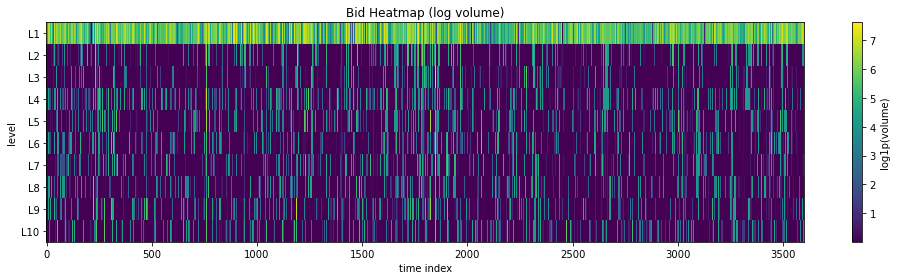

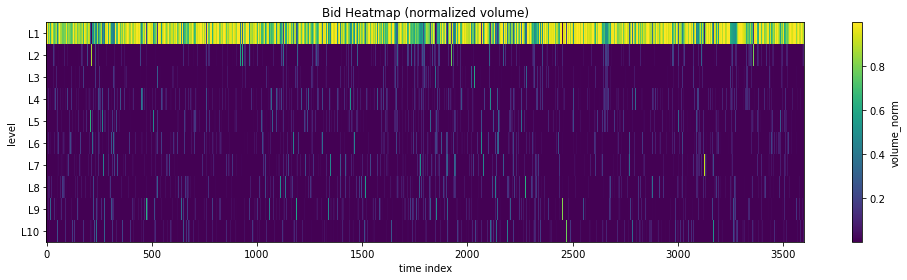

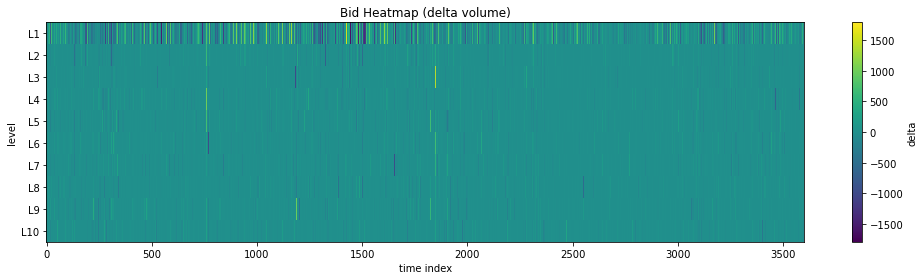

In [11]:
import matplotlib.pyplot as plt

def plot_heatmap(ax, matrix, title, cbar_label):
    im = ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_xlabel("time index")
    ax.set_ylabel("level")
    ax.set_title(title)
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"L{i}" for i in range(1, 11)])
    plt.colorbar(im, ax=ax, label=cbar_label)
    return im

bid_df = long_df[long_df["side"] == "bid"]
levels_sorted = sorted(bid_df["level"].unique())

# A) Bid log-scaled
bid_log = bid_df.pivot_table(index="level", columns="time_idx", values="volume_log", aggfunc="first").fillna(0)
bid_log = bid_log.reindex(levels_sorted)
fig, ax = plt.subplots(figsize=(14, 4))
plot_heatmap(ax, bid_log.values, "Bid Heatmap (log volume)", "log1p(volume)")
plt.tight_layout()
plt.show()

# B) Bid normalized
bid_norm = bid_df.pivot_table(index="level", columns="time_idx", values="volume_norm", aggfunc="first").fillna(0)
bid_norm = bid_norm.reindex(levels_sorted)
fig, ax = plt.subplots(figsize=(14, 4))
plot_heatmap(ax, bid_norm.values, "Bid Heatmap (normalized volume)", "volume_norm")
plt.tight_layout()
plt.show()

# C) Bid delta
bid_delta = bid_df.pivot_table(index="level", columns="time_idx", values="delta_volume", aggfunc="first").fillna(0)
bid_delta = bid_delta.reindex(levels_sorted)
fig, ax = plt.subplots(figsize=(14, 4))
plot_heatmap(ax, bid_delta.values, "Bid Heatmap (delta volume)", "delta")
plt.tight_layout()
plt.show()

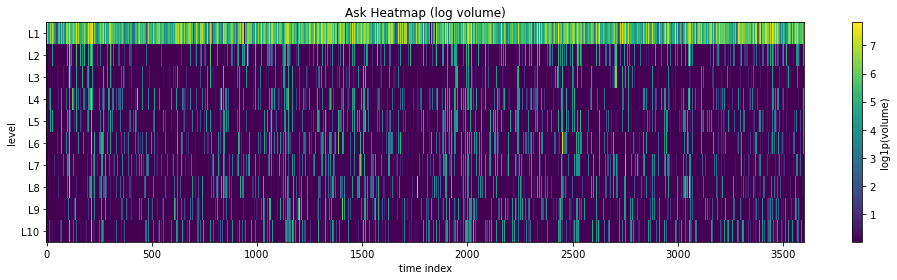

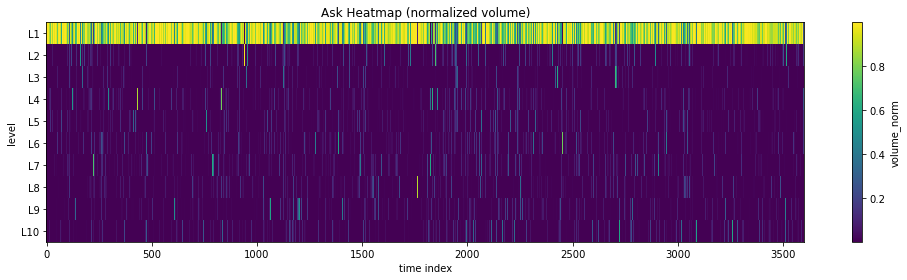

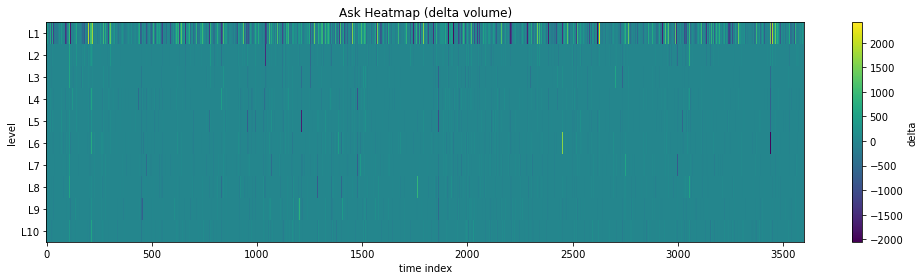

In [12]:
# Ask heatmaps
ask_df = long_df[long_df["side"] == "ask"]
levels_sorted = sorted(ask_df["level"].unique())

# A) Ask log-scaled
ask_log = ask_df.pivot_table(index="level", columns="time_idx", values="volume_log", aggfunc="first").fillna(0)
ask_log = ask_log.reindex(levels_sorted)
fig, ax = plt.subplots(figsize=(14, 4))
plot_heatmap(ax, ask_log.values, "Ask Heatmap (log volume)", "log1p(volume)")
plt.tight_layout()
plt.show()

# B) Ask normalized
ask_norm = ask_df.pivot_table(index="level", columns="time_idx", values="volume_norm", aggfunc="first").fillna(0)
ask_norm = ask_norm.reindex(levels_sorted)
fig, ax = plt.subplots(figsize=(14, 4))
plot_heatmap(ax, ask_norm.values, "Ask Heatmap (normalized volume)", "volume_norm")
plt.tight_layout()
plt.show()

# C) Ask delta
ask_delta = ask_df.pivot_table(index="level", columns="time_idx", values="delta_volume", aggfunc="first").fillna(0)
ask_delta = ask_delta.reindex(levels_sorted)
fig, ax = plt.subplots(figsize=(14, 4))
plot_heatmap(ax, ask_delta.values, "Ask Heatmap (delta volume)", "delta")
plt.tight_layout()
plt.show()